# Case Category Analysis

This notebook analyzes the revised historical collapse dataset at the category level. It treats `9` as structured unknown data rather than as a numeric score and focuses on exploratory comparison across cases.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

plt.style.use("default")
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)

In [2]:
project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent

src_dir = project_root / "src"
if str(src_dir) not in sys.path:
    sys.path.append(str(src_dir))

from config import COLLAPSE_DATASET_PATH
from dataset_utils import get_factor_columns, load_collapse_dataset

factor_categories = {
    "political": [
        "political_fragmentation",
        "elite_conflict",
        "succession_crisis",
        "legitimacy_crisis",
        "administrative_overload",
        "corruption_governance_failure",
    ],
    "social": [
        "social_inequality",
        "social_unrest_rebellion",
        "demographic_pressure",
        "migration_pressure",
        "ethnic_sectarian_fragmentation",
        "urban_decline",
    ],
    "economic": [
        "fiscal_crisis",
        "taxation_extraction_pressure",
        "trade_disruption",
        "inflation_currency_instability",
        "resource_dependency",
        "agricultural_decline",
    ],
    "environmental": [
        "drought_climate_stress",
        "flood_environmental_shock",
        "temperature_anomaly",
        "ecological_degradation",
        "food_insecurity",
    ],
    "military_geopolitical": [
        "external_invasion_pressure",
        "civil_war_internal_conflict",
        "military_overstretch",
        "territorial_loss",
    ],
    "resilience_institutional": [
        "institutional_rigidity",
        "adaptive_capacity",
        "logistics_food_storage_resilience",
        "alliance_network_strength",
        "recovery_capacity",
    ],
}

df = load_collapse_dataset(COLLAPSE_DATASET_PATH)
factor_cols = get_factor_columns()
factor_data = df[factor_cols].apply(pd.to_numeric, errors="coerce")
known_factor_data = factor_data.where(factor_data.isin([0, 1, 2, 3]))

records = []
for case_name, case_df in df.groupby("case_name", sort=True):
    for category, cols in factor_categories.items():
        category_values = factor_data.loc[case_df.index, cols]
        category_known = known_factor_data.loc[case_df.index, cols]
        total_slots = category_values.shape[0] * category_values.shape[1]
        known_count = int(category_known.notna().sum().sum())
        unknown_count = int(category_values.eq(9).sum().sum())
        avg_known_score = category_known.stack().mean()
        records.append(
            {
                "case_name": case_name,
                "case_type": case_df["case_type"].iloc[0],
                "category": category,
                "avg_known_score": avg_known_score,
                "known_count": known_count,
                "unknown_prop": unknown_count / total_slots if total_slots else np.nan,
            }
        )

category_metrics = pd.DataFrame(records)
category_avg_by_case = category_metrics.pivot(index="case_name", columns="category", values="avg_known_score").round(2)
category_known_by_case = category_metrics.pivot(index="case_name", columns="category", values="known_count").astype(int)
category_unknown_by_case = category_metrics.pivot(index="case_name", columns="category", values="unknown_prop")
category_unknown_pct_by_case = (category_unknown_by_case * 100).round(1)

case_summary = df.groupby("case_name").agg(
    case_type=("case_type", "first"),
    rows=("case_id", "size"),
    avg_collapse_outcome=("collapse_outcome", "mean"),
)
case_summary["avg_collapse_outcome"] = case_summary["avg_collapse_outcome"].round(2)
case_summary["overall_unknown_prop"] = (
    factor_data.eq(9).sum(axis=1).groupby(df["case_name"]).mean() / len(factor_cols)
).round(3)
case_summary["era_group"] = case_summary["case_type"].map(
    lambda value: "modern" if value == "modern" else "ancient_premodern"
)
uncertainty_threshold = case_summary["overall_unknown_prop"].median()
case_summary["uncertainty_group"] = np.where(
    case_summary["overall_unknown_prop"] >= uncertainty_threshold,
    "high_uncertainty",
    "lower_uncertainty",
)

collapse_outcome_ranking = case_summary[["case_type", "rows", "avg_collapse_outcome", "overall_unknown_prop"]].sort_values(
    ["avg_collapse_outcome", "overall_unknown_prop"],
    ascending=[False, False],
)

df.shape

(174, 45)

## Case-Level Category Tables

The tables below summarize each case by category. Average scores use only known values (`0` to `3`), while `9` is excluded from the mean and tracked separately as uncertainty.

In [3]:
display(category_avg_by_case)
display(category_known_by_case)
display(category_unknown_pct_by_case)

category,economic,environmental,military_geopolitical,political,resilience_institutional,social
case_name,,,,,,
Akkadian Empire,1.67,1.23,1.81,1.58,1.72,1.39
Aztec Empire,1.26,1.00,1.30,1.38,1.88,1.25
Bronze Age Collapse States,1.54,1.18,1.59,1.61,1.52,1.31
Byzantine Decline,1.75,1.68,2.18,1.93,1.53,1.75
Classic Mesopotamian States,1.44,1.24,1.58,1.84,1.68,1.33
Easter Island,1.10,1.48,0.00,NaN,2.05,0.46
Han Dynasty Crisis,1.81,1.22,2.14,2.11,1.49,1.75
Inca Empire,1.07,0.57,1.14,1.28,2.03,1.18
Khmer Empire,1.38,1.28,1.29,1.43,1.82,1.22


category,economic,environmental,military_geopolitical,political,resilience_institutional,social
case_name,,,,,,
Akkadian Empire,36,13,32,43,40,23
Aztec Empire,23,5,20,26,25,16
Bronze Age Collapse States,26,11,22,23,40,16
Byzantine Decline,93,19,76,109,95,68
Classic Mesopotamian States,86,21,74,92,100,52
Easter Island,60,46,60,0,80,100
Han Dynasty Crisis,31,9,28,38,35,24
Inca Empire,29,7,28,36,35,17
Khmer Empire,81,32,72,97,90,51


category,economic,environmental,military_geopolitical,political,resilience_institutional,social
case_name,,,,,,
Akkadian Empire,25.0,67.5,0.0,10.4,0.0,52.1
Aztec Empire,23.3,80.0,0.0,13.3,0.0,46.7
Bronze Age Collapse States,45.8,72.5,31.2,52.1,0.0,66.7
Byzantine Decline,18.4,80.0,0.0,4.4,0.0,40.4
Classic Mesopotamian States,28.3,79.0,7.5,23.3,0.0,56.7
Easter Island,50.0,54.0,25.0,100.0,20.0,16.7
Han Dynasty Crisis,26.2,74.3,0.0,9.5,0.0,42.9
Inca Empire,31.0,80.0,0.0,14.3,0.0,59.5
Khmer Empire,25.0,64.4,0.0,10.2,0.0,52.8


## Heatmap Of Category Averages By Case

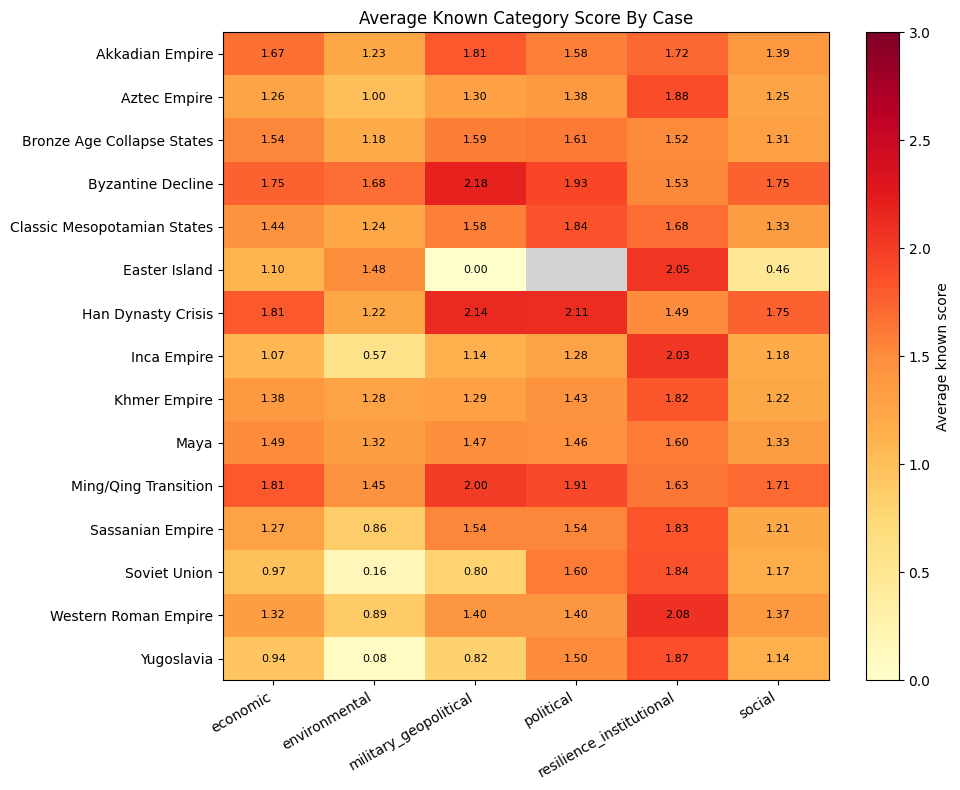

In [4]:
heatmap_data = category_avg_by_case.copy()
matrix = np.ma.masked_invalid(heatmap_data.to_numpy())
cmap = plt.cm.YlOrRd.copy()
cmap.set_bad(color="lightgray")

fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(matrix, aspect="auto", cmap=cmap, vmin=0, vmax=3)
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, rotation=30, ha="right")
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
ax.set_title("Average Known Category Score By Case")

for row_idx, case_name in enumerate(heatmap_data.index):
    for col_idx, category in enumerate(heatmap_data.columns):
        value = heatmap_data.loc[case_name, category]
        if pd.notna(value):
            ax.text(col_idx, row_idx, f"{value:.2f}", ha="center", va="center", fontsize=8)

colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Average known score")
plt.tight_layout()
plt.show()

## Uncertainty And Collapse Outcome

These views show where category-level uncertainty remains high and how average `collapse_outcome` differs across cases.

category,economic,environmental,military_geopolitical,political,resilience_institutional,social
case_name,,,,,,
Akkadian Empire,25.0,67.5,0.0,10.4,0.0,52.1
Aztec Empire,23.3,80.0,0.0,13.3,0.0,46.7
Bronze Age Collapse States,45.8,72.5,31.2,52.1,0.0,66.7
Byzantine Decline,18.4,80.0,0.0,4.4,0.0,40.4
Classic Mesopotamian States,28.3,79.0,7.5,23.3,0.0,56.7
Easter Island,50.0,54.0,25.0,100.0,20.0,16.7
Han Dynasty Crisis,26.2,74.3,0.0,9.5,0.0,42.9
Inca Empire,31.0,80.0,0.0,14.3,0.0,59.5
Khmer Empire,25.0,64.4,0.0,10.2,0.0,52.8


,case_type,rows,avg_collapse_outcome,overall_unknown_prop
case_name,,,,
Han Dynasty Crisis,ancient,7,2.14,0.263
Byzantine Decline,premodern,19,1.89,0.243
Bronze Age Collapse States,ancient,8,1.75,0.461
Ming/Qing Transition,premodern,6,1.67,0.250
Akkadian Empire,ancient,8,1.50,0.270
Classic Mesopotamian States,ancient,20,1.40,0.336
Soviet Union,modern,5,1.40,0.000
Sassanian Empire,ancient,7,1.29,0.304
Maya,ancient,14,1.21,0.359


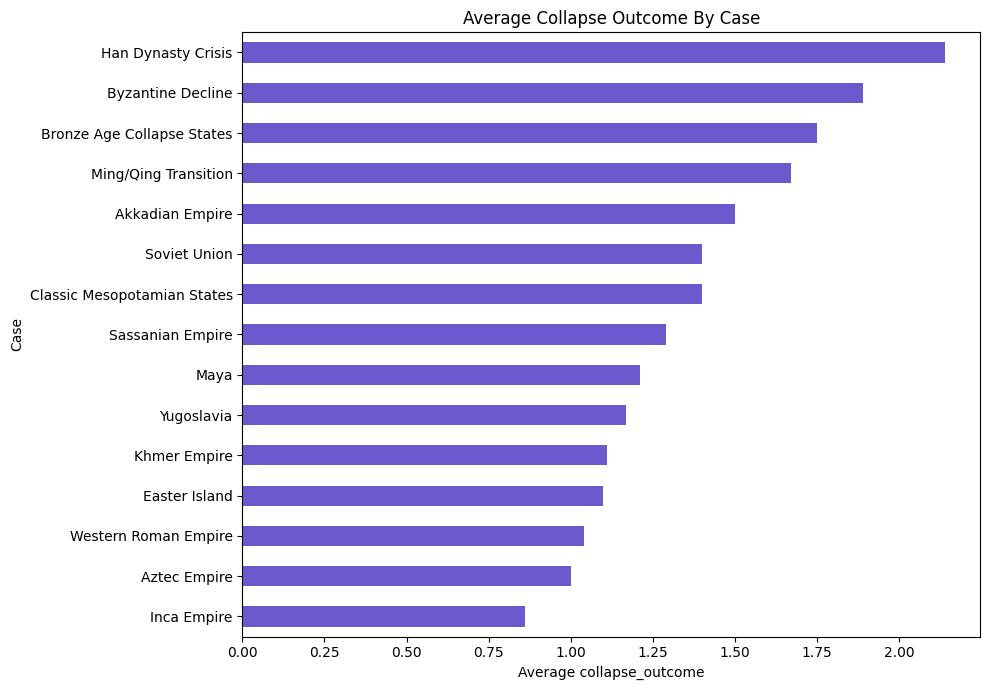

In [5]:
display(category_unknown_pct_by_case)
display(collapse_outcome_ranking)

fig, ax = plt.subplots(figsize=(10, 7))
collapse_outcome_ranking["avg_collapse_outcome"].sort_values().plot(kind="barh", ax=ax, color="slateblue")
ax.set_title("Average Collapse Outcome By Case")
ax.set_xlabel("Average collapse_outcome")
ax.set_ylabel("Case")
plt.tight_layout()
plt.show()

## Comparative Slices

This section compares `ancient + premodern` cases against `modern` cases and also compares `high_uncertainty` cases against `lower_uncertainty` cases.

In [6]:
era_category_means = (
    category_avg_by_case.join(case_summary[["era_group"]])
    .groupby("era_group")
    .mean()
    .round(2)
)
era_unknown_means = (
    category_unknown_pct_by_case.join(case_summary[["era_group"]])
    .groupby("era_group")
    .mean()
    .round(1)
)

uncertainty_category_means = (
    category_avg_by_case.join(case_summary[["uncertainty_group"]])
    .groupby("uncertainty_group")
    .mean()
    .round(2)
)
uncertainty_group_summary = case_summary.groupby("uncertainty_group").agg(
    cases=("case_type", "size"),
    avg_unknown_prop=("overall_unknown_prop", "mean"),
    avg_collapse_outcome=("avg_collapse_outcome", "mean"),
).round(2)

display(era_category_means)
display(era_unknown_means)
display(uncertainty_category_means)
display(uncertainty_group_summary)

def top_categories(series, n=2):
    return ", ".join(series.sort_values(ascending=False).head(n).index.tolist())

ancient_top = top_categories(era_category_means.loc["ancient_premodern"])
modern_top = top_categories(era_category_means.loc["modern"])
high_unc_top = top_categories(uncertainty_category_means.loc["high_uncertainty"])
low_unc_top = top_categories(uncertainty_category_means.loc["lower_uncertainty"])

summary_md = f"""
### Short Comparison Notes

- Ancient and premodern cases show their highest average known category scores in **{ancient_top}**.
- Modern cases show their highest average known category scores in **{modern_top}**.
- Higher-uncertainty cases are concentrated where archaeology, regional heterogeneity, or debated environmental interpretation leave more factors unknown; their strongest known categories are **{high_unc_top}**.
- Lower-uncertainty cases are driven more by recent political, territorial, and institutional evidence; their strongest known categories are **{low_unc_top}**.
- The median case-level uncertainty threshold used here is **{uncertainty_threshold:.1%}** unknown factor cells per row.
"""

display(Markdown(summary_md))

,economic,environmental,military_geopolitical,political,resilience_institutional,social
era_group,,,,,,
ancient_premodern,1.45,1.18,1.50,1.62,1.76,1.33
modern,0.96,0.12,0.81,1.55,1.86,1.15


,economic,environmental,military_geopolitical,political,resilience_institutional,social
era_group,,,,,,
ancient_premodern,30.4,72.4,6.4,24.1,1.5,47.3
modern,4.2,6.6,4.2,0.0,0.0,1.4


,economic,environmental,military_geopolitical,political,resilience_institutional,social
uncertainty_group,,,,,,
high_uncertainty,1.31,1.07,1.25,1.50,1.83,1.18
lower_uncertainty,1.48,1.01,1.58,1.72,1.70,1.45


,cases,avg_unknown_prop,avg_collapse_outcome
uncertainty_group,,,
high_uncertainty,8,0.35,1.21
lower_uncertainty,7,0.19,1.55



### Short Comparison Notes

- Ancient and premodern cases show their highest average known category scores in **resilience_institutional, political**.
- Modern cases show their highest average known category scores in **resilience_institutional, political**.
- Higher-uncertainty cases are concentrated where archaeology, regional heterogeneity, or debated environmental interpretation leave more factors unknown; their strongest known categories are **resilience_institutional, political**.
- Lower-uncertainty cases are driven more by recent political, territorial, and institutional evidence; their strongest known categories are **political, resilience_institutional**.
- The median case-level uncertainty threshold used here is **27.2%** unknown factor cells per row.
